In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

TF 2.21.0


This is a simplified dual encoder inspired by the Keras "Natural language image search" example. It pairs tf_flowers images with short text captions so it runs locally. An image encoder and a text encoder map into the same embedding space, and a contrastive loss pulls matching image-text pairs together and pushes non-matching pairs apart.

In [2]:
(train_raw,), info = tfds.load("tf_flowers", split=["train"], as_supervised=True, with_info=True)
class_names = info.features["label"].names
print(class_names)

# One short caption per class
captions_per_class = ["a photo of a " + c for c in class_names]
templates = tf.constant(captions_per_class)


def make_pair(image, label):
    image = tf.image.resize(image, [224, 224])
    image = keras.applications.mobilenet_v2.preprocess_input(image)
    caption = tf.gather(templates, label)
    return image, caption


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_raw.map(make_pair, num_parallel_calls=AUTOTUNE).shuffle(1000).batch(32).prefetch(AUTOTUNE)

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']


The text encoder needs a vocabulary, so we adapt a TextVectorization layer on the captions.

In [3]:
vectorizer = keras.layers.TextVectorization(output_sequence_length=8)
vectorizer.adapt(captions_per_class)
vocab_size = vectorizer.vocabulary_size()
print("vocab size:", vocab_size)

vocab size: 10


The image encoder is a frozen MobileNetV2 followed by a dense projection into a 256-d embedding, which is L2-normalized so that a dot product equals cosine similarity.

In [4]:
embed_dim = 256

base_model = keras.applications.MobileNetV2(weights="imagenet", include_top=False, input_shape=[224, 224, 3])
base_model.trainable = False

image_encoder = keras.Sequential([
    keras.layers.Input(shape=[224, 224, 3]),
    base_model,
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(embed_dim),
    keras.layers.UnitNormalization(),
], name="image_encoder")

The text encoder turns a caption into tokens, embeds them, averages them, and projects into the same 256-d space, also L2-normalized.

In [5]:
text_encoder = keras.Sequential([
    vectorizer,
    keras.layers.Embedding(vocab_size, 128),
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(embed_dim),
    keras.layers.UnitNormalization(),
], name="text_encoder")

The dual encoder trains both encoders together. In each batch it builds a similarity matrix between every image and every caption. The matching pairs sit on the diagonal (the positives) and every other cell is a non-matching pair (an in-batch negative). A contrastive loss makes each image most similar to its own caption and vice versa.

In [6]:
class DualEncoder(keras.Model):
    def __init__(self, image_encoder, text_encoder, temperature=0.05, **kwargs):
        super().__init__(**kwargs)
        self.image_encoder = image_encoder
        self.text_encoder = text_encoder
        self.temperature = temperature
        self.loss_tracker = keras.metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def contrastive_loss(self, images, captions, training):
        image_emb = self.image_encoder(images, training=training)
        text_emb = self.text_encoder(captions, training=training)

        # cosine similarity matrix (embeddings are already L2-normalized)
        logits = tf.matmul(image_emb, text_emb, transpose_b=True) / self.temperature
        labels = tf.range(tf.shape(logits)[0])

        loss_i = keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        loss_t = keras.losses.sparse_categorical_crossentropy(labels, tf.transpose(logits), from_logits=True)
        return (tf.reduce_mean(loss_i) + tf.reduce_mean(loss_t)) / 2

    def train_step(self, data):
        images, captions = data
        with tf.GradientTape() as tape:
            loss = self.contrastive_loss(images, captions, training=True)
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

In [7]:
dual_encoder = DualEncoder(image_encoder, text_encoder)
dual_encoder.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

history = dual_encoder.fit(train_ds, epochs=5)

Epoch 1/5


/Users/ducnguyen/Desktop/AIT506/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1786484728.801796 24935723 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


115/115 ━━━━━━━━━━━━━━━━━━━━ 14s 99ms/step - loss: 2.4791
Epoch 2/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 92ms/step - loss: 2.2193
Epoch 3/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 2.1452
Epoch 4/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - loss: 2.1069
Epoch 5/5
115/115 ━━━━━━━━━━━━━━━━━━━━ 10s 90ms/step - loss: 2.0818


We evaluate with a zero-shot classification test: embed the five class captions as prototypes, embed each test image, and predict the class whose caption is most similar (highest cosine similarity). Accuracy tells us how well text and image embeddings are aligned.

In [8]:
# Collect a test set
test_images, test_labels = [], []
for image, label in tfds.load("tf_flowers", split="train[80%:]", as_supervised=True).take(400):
    test_images.append(tf.image.resize(image, [224, 224]))
    test_labels.append(int(label))

test_images = tf.stack(test_images)
test_labels = np.array(test_labels)
test_prep = keras.applications.mobilenet_v2.preprocess_input(tf.identity(test_images))

# Embed images and the class-caption prototypes
image_emb = image_encoder.predict(test_prep, verbose=0)
proto_emb = text_encoder.predict(tf.constant(captions_per_class), verbose=0)

# Predict class = most similar caption
sims = image_emb @ proto_emb.T
preds = sims.argmax(axis=1)
accuracy = (preds == test_labels).mean()
print(f"Zero-shot accuracy: {accuracy:.4f}")

W0000 00:00:1786484783.355383 24937008 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


Zero-shot accuracy: 0.9975


Finally, a text search demo: type a prompt, embed it, and retrieve the images whose embeddings are the most similar.

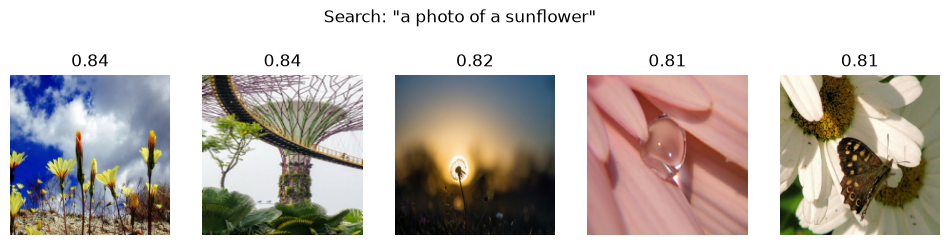

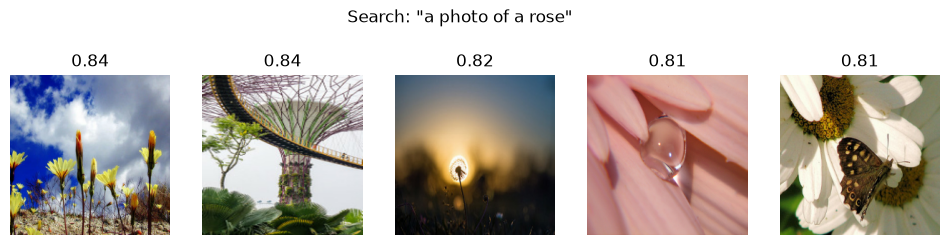

In [9]:
def search(prompt, k=5):
    query_emb = text_encoder.predict(tf.constant([prompt]), verbose=0)
    scores = (image_emb @ query_emb.T)[:, 0]
    top = scores.argsort()[::-1][:k]

    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(top):
        plt.subplot(1, k, i + 1)
        plt.imshow(test_images[idx].numpy().astype("uint8"))
        plt.title(f"{scores[idx]:.2f}")
        plt.axis("off")
    plt.suptitle(f'Search: "{prompt}"')
    plt.show()


search("a photo of a sunflower")
search("a photo of a rose")